In [22]:

import numpy as np
from deap import base, creator, tools, algorithms
from scipy.signal import cont2discrete 



def lagd(a, N):
    v = np.zeros(N)
    Lo = np.zeros(N)
    v[0] = a
    Lo[0] = 1

    for k in range(1, N):
        v[k] = ((-a) ** (k - 1)) * (1 - a * a)
        Lo[k] = (-a) ** (k)

    Lo = np.sqrt((1 - a * a)) * Lo
    # Lo = Lo.reshape(-1,1)
    A = np.zeros((N, N))
    A[:, 0] = v

    for i in range(1, N):
        A[:, i] = np.concatenate([np.zeros(i), v[0:N - i]])
    # print(Lo)
    return A, Lo

def dmpc(Ae, Be, a, N, Np, Q, R):
    #Ae and Be are the matrices of the augmented system when integrator is used 
    # They can also be other forms of state space model 
    # a is the parameter of the laguerre network
    # N is the number of terms for each input
    # Np is the prediction horizon
    # Q and R are the cost matrices

    #cost function is J = eta^T E eta + 2 eta^T H x(k_i) 
    #Δui(k) = Li(k)T ηi,

    n, _ = Be.shape
    n_in = 1
    Npa = N[0]  # dimention of eta = sum of all the values of Ns
    E = np.zeros((Npa,Npa))
    H = np.zeros((Npa,n))
    R_para = np.zeros((Npa,Npa))
    n0 = 0
    ne = N[0] 
    for i in range(0,n_in):
        R_para[n0:ne,n0:ne] = R[i,i]*np.eye(N[i],N[i])

    # Now initial condition for the convolution sum 
    Sin = np.zeros((n,Npa))
    
    [A1,Lo] = lagd(a[0],N[0])
    Lo = Lo.reshape(-1, 1)
    # print(Be.shape, Lo.shape)
    Sin[:,0:N[0]] = Be@np.transpose(Lo)
 
    Sc = Sin
    E = np.transpose(Sc)@Q@Sc
    H = np.transpose(Sc)@Q@Ae
## The iteration i is with respect to the prediction horizon 
    for i in range(0,Np):
        Eae = np.linalg.matrix_power(Ae, i+1)
        [A1,Lo] = lagd(a[0],N[0])
        Lo = Lo.reshape(-1,1)
        Sc[:,0:N[0]] = np.linalg.matrix_power(Ae, i-1)@Sc[:,0:N[0]] + Be@np.transpose(np.linalg.matrix_power(A1, i-1)@Lo)
        E = E + np.transpose(Sc)@Q@Sc
        H = H + np.transpose(Sc)@Q@Eae
    E = E + R_para

    return E,H

def Mdu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    Lzerot = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(2, Nc+1):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = np.vstack((M, M_du1))

    return M, Lzerot

def QPHild(E, F, M, gamma):
    # inputs are H f A_cons b  in order 
    # Determine which constraints are active and which are inactive
    n1 = M.shape[0]
    m1 = M.shape[1]
    eta = -np.linalg.solve(E, F)
    kk = 0

    for i in range(n1):
        if np.dot(M[i], eta) > gamma[i]:
            kk += 1

    if kk == 0:
        return eta

    P = np.dot(M,np.dot(np.linalg.inv(E),M.T))
    d = np.dot(M,np.dot(np.linalg.inv(E),F)) + gamma

    n, m = d.shape
    x_ini = np.zeros((n, m))
    lam = x_ini
    al = 10
    
    # 40 is the number of iterations to
    for km in range(40):
        lambda_p = np.copy(lam)
        
        for i in range(n):
            w = np.dot(P[i,:],lam) - np.dot(P[i,i],lam[i])
            w = w + d[i]
            la = -w/P[i,i]
            lam[i,0] = max(0,la)
            #print(lam[i,0])
        al = np.dot((lam-lambda_p).T,lam-lambda_p)
        
        if al < 10e-8:
            break

    eta = eta  - np.dot(np.linalg.solve(E, M.T), lam)
    return eta

def Mu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    M1 = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(1, Nc):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = M + M_du1
        M1 = np.vstack((M1, M))

    return M1

def exp_matrix(size, alpha):
    I = np.zeros((size,size))
    for i in range(0,size):
        I[i,i] = pow(alpha,i)

    return I

## Constrints are clamping type
def simCon3(xm, u, y, yr, Ae, Be, Ce, N_sim, Omega, Psi, Lzerot, M0, M1, I):
    m1, n1 = Ce.shape
    # n1, _ = Bp.shape
    n_in = 1
    Lzerot = Lzerot.reshape(-1,1)

    u_max = 2.5
    u_min = -3.5
    delu_min = -5
    delu_max = 3.5
    Nc = 15   # number of steps on which limit has to be imposed 
    M = np.vstack((M0,-M0,M1, -M1))
    M = M@I

    u1 = np.zeros((n_in, N_sim))
    y1 = np.zeros((m1, N_sim))
    deltau1 = np.zeros((n_in, N_sim))
    xf = np.vstack((xm, (y - yr)))

    cost = 0

    for kk in range(N_sim):
        u_prev = u
        gamma = np.vstack(((u_max - u_prev) * np.ones((Nc, 1)),
                    -(u_min - u_prev) * np.ones((Nc, 1))
                    , delu_max * np.ones((Nc,1))
                    , -delu_min * np.ones((Nc,1))))
        # print(f"this is Omega {Omega.shape}, Psi {Psi.shape}, M {M.shape}, gamma {gamma.shape}")
        eta = QPHild(Omega, Psi@xf, M, gamma)
        # Kmpc = np.transpose(Lzerot) @ np.linalg.solve(Omega, Psi)
        # Ke = Kmpc[0,3:6].reshape(1,-1)
        deltau = np.transpose(Lzerot) @ eta   # 
        if deltau[0] > delu_max:
            deltau[0] = delu_max
        if deltau[0] < delu_min:
            deltau[0] = delu_min
        u += deltau
        if u[0] > u_max:
            u[0] = u_max
        if u[0] < u_min:
            u[0] = u_min
            
        deltau1[:, kk] = deltau
        u1[:, kk] = u
        xm_old = xm.copy()
        xm = Ae@xm + Be@u
        y = Ce@xm 
        
        cost += xm@xm.T/ np.linalg.norm(xm, 'fro') + u*u  # yr is actually 0
        if xm[0] < 0:
            cost += 5*xm@xm.T/ np.linalg.norm(xm, 'fro')


        y1[:,kk] = y.reshape(3,)
        xf = np.vstack((xm - xm_old, y - yr)) #Xf = np.vstack((xm - xm_old, y - sp[:, kk + 1]))

    cost += 25*y@y.T/ np.linalg.norm(y, 'fro')

    return cost



T_eng =  0.460 #0.26  #
K_eng = 0.732
A_f = -1/T_eng
B_f = K_eng/T_eng
C = np.eye(3)
T_hw = 3
Ts = 0.05
T_total = 10
T = int(T_total/Ts)


# Discretize the system
A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
B = np.array([[0], [0], [B_f]])
sys2 = cont2discrete((A,B, C, 0), Ts, method='zoh')
A, B, C, D , dt = sys2

m1,n1 = C.shape  # m1 = 3, n1 = 3
n1,n_in = B.shape  # n_in = 1

Np = 30

# Augment the state equations 
Ae = np.eye(n1+m1,n1+m1)
Ae[0:n1,0:n1] = A
Ae[n1:n1+m1,0:n1] = C@A
Be = np.zeros((n1+m1,n_in))
Be[0:n1,:] = B
Be[n1:n1+m1,:] = C@B
Ce = np.zeros((m1,n1+m1))
Ce[:,n1:n1+m1] = np.eye(m1,m1)
N_sim = T
Nc = 15

Q = np.transpose(Ce)@Ce
R = np.eye(1,1)
u = np.zeros((n_in, 1))
xm = np.array([[50], [10], [2]])
y = xm.copy()
yr = np.array([[0], [0], [0]])



# Define GA parameters
population_size = 10
generations = 3
crossover_prob = 0.8
mutation_prob = 0.1

# Define fitness function
# Logic for selecting the best weights 
# how close the solution is to the reference and low input control

def fitness(weights): 

    # Define cost function
    # wei = np.array( [2.3402147,  0.13887758, 8.62801652, 7.07007845, 3.90228481, 8.64458343, 9.36867319, 7.64481834])
    
    a1 = weights[0]
    N1 = int(weights[1])
    a = [a1]
    N = [N1]
    # print(f"this is a {a}, and this is N {N}")
    try:
        M1, Lzerot = Mdu(a, N,Nc,n_in)
        M0 = Mu(a, N,Nc,n_in)
        _, Lz = lagd(a[0], N[0])
        alpha = 1.02
        I = exp_matrix(N[0], alpha)
        Omega, Psi = dmpc(Ae/alpha, Be/alpha, a, N, Np, Q, R)
        # Constraints are defined inside simcon2
        cost=-1*simCon3(xm,u,y,yr,A,B,C,N_sim,Omega,Psi,Lz,M0, M1,I)
    except Exception:
        cost = -100000
    # Always return a tuple, even if it's a single value
    cost = np.sum(cost)
    # if cost!= -100000:
    #     print(f"this is the cost {cost}")
    return cost,


def init_individual(icls, variable_ranges):
    values = [
        np.random.uniform(low, high) if idx == 0 else np.random.randint(low, high + 1) 
        for idx, (low, high) in enumerate(variable_ranges)
    ]
    # print(f"Initialized individual with values: {values}")
    return icls(values)


def run_ga(population_size, generations, crossover_prob, mutation_prob, num_best=10):
    # Create genetic algorithm toolbox
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", np.ndarray, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    variable_ranges = [(0.1, 0.99), (3, 15)]  # First variable is a float, second variable is an integer
    toolbox.register("individual", init_individual, creator.Individual, variable_ranges)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual, n=population_size)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("evaluate", fitness)

    # Initialize population
    population = toolbox.population(n=population_size)
    best_individuals = []
    # Evolve population
    for gen in range(generations):
        offspring = []

        # Apply crossover and mutation to population
        for i in range(0, population_size, 2):
            ind1 = population[i]
            ind2 = population[i+1]
            if np.random.random() < crossover_prob:
                offspring1, offspring2 = toolbox.mate(ind1, ind2)
                del offspring1.fitness.values
                del offspring2.fitness.values
                offspring.append(offspring1)
                offspring.append(offspring2)
            else:
                offspring.append(ind1)
                offspring.append(ind2)

        # Apply mutation to offspring
        for ind in offspring:
            if np.random.random() < mutation_prob:
                toolbox.mutate(ind)
                del ind.fitness.values

        # Evaluate fitness of offspring
        fitnesses = list(map(toolbox.evaluate, offspring))
        for ind, fit in zip(offspring, fitnesses):
            ind.fitness.values = fit

        # Replace population with offspring
        population[:] = offspring

        best_individuals.extend(list(offspring + population))

    # Select the best individual from the final population
    best_individuals = tools.selBest(best_individuals, k=num_best)

    for i, ind in enumerate(best_individuals):
        print(f"Rank {i+1} - Fitness: {fitness(ind)}, Variables: {ind}")

    return best_individuals

# Run genetic algorithm
best_weights = run_ga(population_size, generations, crossover_prob, mutation_prob, num_best=10)


c:\Users\Harshin N\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\Harshin N\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Rank 1 - Fitness: (-26123.736303412807,), Variables: [ 0.35606287 14.        ]
Rank 2 - Fitness: (-26123.736303412807,), Variables: [ 0.35606287 14.        ]
Rank 3 - Fitness: (-26123.736303412807,), Variables: [ 0.35606287 14.        ]
Rank 4 - Fitness: (-26123.736303412807,), Variables: [ 0.35606287 14.        ]
Rank 5 - Fitness: (-26123.736303412807,), Variables: [ 0.35606287 14.        ]
Rank 6 - Fitness: (-26123.736303412807,), Variables: [ 0.35606287 14.        ]
Rank 7 - Fitness: (-25227.92867288906,), Variables: [ 0.41656994 12.        ]
Rank 8 - Fitness: (-25227.92867288906,), Variables: [ 0.41656994 12.        ]
Rank 9 - Fitness: (-25227.92867288906,), Variables: [ 0.41656994 12.        ]
Rank 10 - Fitness: (-25227.92867288906,), Variables: [ 0.41656994 12.        ]


this is the condition number 1454.8342493084415
this is max modulus 0.9999999999999996


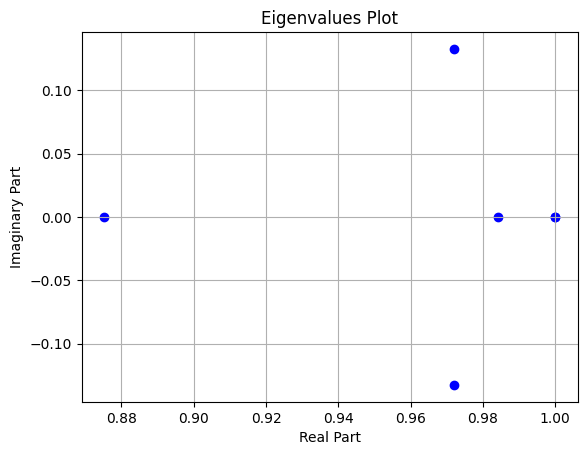

In [218]:
import matplotlib.pyplot as plt
## For choosing alpha for stable eig value
## All the eig values modulus should be less than 1
## can warry a and alpha
Q = np.transpose(Ce)@Ce
R = np.eye(1,1)
a = best_weights[-1][0]
N = best_weights[-1][1]

alpha = 1.02
Omega, Psi = dmpc(Ae/alpha, Be/alpha, a, N, Np, Q, R)
condition_number = np.linalg.cond(Omega)
print(f"this is the condition number {condition_number}")

L_m=np.zeros((1,N[0]))
[A1,L0]=lagd(a[0],N[0])
L_m[0,0:N[0]]=np.transpose(L0)

# print(L_m.shape, Omega.shape, Psi.shape)
k1 = np.linalg.solve(Omega, Psi)

K = L_m@k1
Acl=Ae - Be@K

eigenvalues = np.linalg.eigvals(Acl)
modi = np.zeros((6,1))
i = 0
for eig in eigenvalues:
    mod = eig.real **2 + eig.imag **2
    modi[i] = mod**0.5
    
print( f"this is max modulus {np.max(mod)}")

# Plot the eigenvalues on the complex plane
plt.scatter(eigenvalues.real, eigenvalues.imag, color='blue')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.title('Eigenvalues Plot')
plt.grid(True)
plt.show()

In [215]:
print(best_weights)
print(best_weights[-1])
print(best_weights[-1][0])
print(best_weights[-1][1])

[0.14345293 7.81078453 0.61564687 2.49003997 9.59843561 9.36721826
 1.78778609]
1.7877860880135767


IndexError: invalid index to scalar variable.

In [217]:

import numpy as np
from deap import base, creator, tools, algorithms
from scipy.signal import cont2discrete 

T_eng =  0.460 #0.26  #
K_eng = 0.732
A_f = -1/T_eng
B_f = K_eng/T_eng
C = np.eye(3)
T_hw = 3
Ts = 0.05
T_total = 10
T = int(T_total/Ts)

# Discretize the system
A = np.array([[0, 1, -T_hw], [0, 0, -1], [0, 0, A_f]])
B = np.array([[0], [0], [B_f]])
sys2 = cont2discrete((A,B, C, 0), Ts, method='zoh')
A, B, C, D , dt = sys2

m1,n1 = C.shape  # m1 = 3, n1 = 3
n1,n_in = B.shape  # n_in = 1

Np = 40
besta = best_weights[-1][0]
bestN = best_weights[-1][1]
a = [besta]
N = [bestN]

# Augment the state equations 
Ae = np.eye(n1+m1,n1+m1)
Ae[0:n1,0:n1] = A
Ae[n1:n1+m1,0:n1] = C@A
Be = np.zeros((n1+m1,n_in))
Be[0:n1,:] = B
Be[n1:n1+m1,:] = C@B
Ce = np.zeros((m1,n1+m1))
Ce[:,n1:n1+m1] = np.eye(m1,m1)


# Define GA parameters
population_size = 150
generations = 40
crossover_prob = 0.75
mutation_prob = 0.4


def lagd(a, N):
    v = np.zeros(N)
    Lo = np.zeros(N)
    v[0] = a
    Lo[0] = 1

    for k in range(1, N):
        v[k] = ((-a) ** (k - 1)) * (1 - a * a)
        Lo[k] = (-a) ** (k)

    Lo = np.sqrt((1 - a * a)) * Lo
    # Lo = Lo.reshape(-1,1)
    A = np.zeros((N, N))
    A[:, 0] = v

    for i in range(1, N):
        A[:, i] = np.concatenate([np.zeros(i), v[0:N - i]])
    # print(Lo)
    return A, Lo

def dmpc(Ae, Be, a, N, Np, Q, R):
    #Ae and Be are the matrices of the augmented system when integrator is used 
    # They can also be other forms of state space model 
    # a is the parameter of the laguerre network
    # N is the number of terms for each input
    # Np is the prediction horizon
    # Q and R are the cost matrices

    #cost function is J = eta^T E eta + 2 eta^T H x(k_i) 
    #Δui(k) = Li(k)T ηi,

    n, _ = Be.shape
    n_in = 1
    Npa = N[0]  # dimention of eta = sum of all the values of Ns
    E = np.zeros((Npa,Npa))
    H = np.zeros((Npa,n))
    R_para = np.zeros((Npa,Npa))
    n0 = 0
    ne = N[0] 
    for i in range(0,n_in):
        R_para[n0:ne,n0:ne] = R[i,i]*np.eye(N[i],N[i])

    # Now initial condition for the convolution sum 
    Sin = np.zeros((n,Npa))
    
    [A1,Lo] = lagd(a[0],N[0])
    Lo = Lo.reshape(-1, 1)
    # print(Be.shape, Lo.shape)
    Sin[:,0:N[0]] = Be@np.transpose(Lo)
 
    Sc = Sin
    E = np.transpose(Sc)@Q@Sc
    H = np.transpose(Sc)@Q@Ae
## The iteration i is with respect to the prediction horizon 
    for i in range(0,Np):
        Eae = np.linalg.matrix_power(Ae, i+1)
        [A1,Lo] = lagd(a[0],N[0])
        Lo = Lo.reshape(-1,1)
        Sc[:,0:N[0]] = np.linalg.matrix_power(Ae, i-1)@Sc[:,0:N[0]] + Be@np.transpose(np.linalg.matrix_power(A1, i-1)@Lo)
        E = E + np.transpose(Sc)@Q@Sc
        H = H + np.transpose(Sc)@Q@Eae
    E = E + R_para

    return E,H

def Mdu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    Lzerot = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(2, Nc+1):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = np.vstack((M, M_du1))

    return M, Lzerot

def QPHild(E, F, M, gamma):
    # inputs are H f A_cons b  in order 
    # Determine which constraints are active and which are inactive
    n1 = M.shape[0]
    m1 = M.shape[1]
    eta = -np.linalg.solve(E, F)
    kk = 0

    for i in range(n1):
        if np.dot(M[i], eta) > gamma[i]:
            kk += 1

    if kk == 0:
        return eta

    P = np.dot(M,np.dot(np.linalg.inv(E),M.T))
    d = np.dot(M,np.dot(np.linalg.inv(E),F)) + gamma

    n, m = d.shape
    x_ini = np.zeros((n, m))
    lam = x_ini
    al = 10
    
    # 40 is the number of iterations to
    for km in range(40):
        lambda_p = np.copy(lam)
        
        for i in range(n):
            w = np.dot(P[i,:],lam) - np.dot(P[i,i],lam[i])
            w = w + d[i]
            la = -w/P[i,i]
            lam[i,0] = max(0,la)
            #print(lam[i,0])
        al = np.dot((lam-lambda_p).T,lam-lambda_p)
        
        if al < 10e-8:
            break

    eta = eta  - np.dot(np.linalg.solve(E, M.T), lam)
    return eta

def Mu(a, N, Nc, n_in=1):
    N_pa = np.sum(N)
    M = np.zeros((n_in, N_pa))
    M_du1 = np.zeros((n_in, N_pa))
    k0 = 0
    Al, L0 = lagd(a[k0], N[k0])
    M_du1[k0, :N[k0]] = np.transpose(L0)
    cc = N[k0]

    for k0 in range(1, n_in):
        Al, L0 = lagd(a[k0], N[k0])
        M_du1[k0, cc:cc+N[k0]] = np.transpose(L0)
        cc += N[k0]

    M1 = np.copy(M_du1)
    M = np.copy(M_du1)

    for kk in range(1, Nc):
        k0 = 0
        Al, L0 = lagd(a[k0], N[k0])
        L = np.linalg.matrix_power(Al, kk-1) @ L0
        M_du1[k0, :N[k0]] = np.transpose(L)
        cc = N[k0]

        M = M + M_du1
        M1 = np.vstack((M1, M))

    return M1

def exp_matrix(size, alpha):
    I = np.zeros((size,size))
    for i in range(0,size):
        I[i,i] = pow(alpha,i)

    return I

## Constrints are clamping type
def simCon3(xm, u, y, yr, Ae, Be, Ce, N_sim, Omega, Psi, Lzerot, M0, M1, I):
    m1, n1 = Ce.shape
    # n1, _ = Bp.shape
    n_in = 1
    Lzerot = Lzerot.reshape(-1,1)

    u_max = 2.5
    u_min = -3.5
    delu_min = -5
    delu_max = 3.5
    Nc = 15   # number of steps on which limit has to be imposed 
    M = np.vstack((M0,-M0,M1, -M1))
    M = M@I

    u1 = np.zeros((n_in, N_sim))
    y1 = np.zeros((m1, N_sim))
    deltau1 = np.zeros((n_in, N_sim))
    xf = np.vstack((xm, (y - yr)))

    cost = 0

    for kk in range(N_sim):
        u_prev = u
        gamma = np.vstack(((u_max - u_prev) * np.ones((Nc, 1)),
                    -(u_min - u_prev) * np.ones((Nc, 1))
                    , delu_max * np.ones((Nc,1))
                    , -delu_min * np.ones((Nc,1))))
        # print(f"this is Omega {Omega.shape}, Psi {Psi.shape}, M {M.shape}, gamma {gamma.shape}")
        eta = QPHild(Omega, Psi@xf, M, gamma)
        # Kmpc = np.transpose(Lzerot) @ np.linalg.solve(Omega, Psi)
        # Ke = Kmpc[0,3:6].reshape(1,-1)
        deltau = np.transpose(Lzerot) @ eta   # 
        if deltau[0] > delu_max:
            deltau[0] = delu_max
        if deltau[0] < delu_min:
            deltau[0] = delu_min
        u += deltau
        if u[0] > u_max:
            u[0] = u_max
        if u[0] < u_min:
            u[0] = u_min
            
        deltau1[:, kk] = deltau
        u1[:, kk] = u
        xm_old = xm.copy()
        xm = Ae@xm + Be@u
        y = Ce@xm 
        
        cost += xm@xm.T/ np.linalg.norm(xm, 'fro') + u*u  # yr is actually 0
        if xm[0] < 0:
            cost += 5*xm@xm.T/ np.linalg.norm(xm, 'fro')


        y1[:,kk] = y.reshape(3,)
        xf = np.vstack((xm - xm_old, y - yr)) #Xf = np.vstack((xm - xm_old, y - sp[:, kk + 1]))

    cost += 25*y@y.T/ np.linalg.norm(y, 'fro')

    return cost

N_sim = 2
# Define fitness function
def fitness(weights):
    Q =  np.diag(weights[:6])
    R = np.eye(1)*weights[6]
    # Define cost function
    try:
        M1, Lzerot = Mdu(a, N,Nc,n_in)
        M0 = Mu(a, N,Nc,n_in)
        _, Lz = lagd(a[0], N[0])
        alpha = 1.02
        I = exp_matrix(N[0], alpha)
        Omega, Psi = dmpc(Ae/alpha, Be/alpha, a, N, Np, Q, R)
        cost= -1*simCon3(xm,u,y,yr,A,B,C,N_sim,Omega,Psi,Lz,M0, M1,I)
    except Exception:
        cost = -100000
    
    # Always return a tuple, even if it's a single value
    cost = np.sum(cost)
    return cost,

def init_individual(icls, low, high, size):
    return icls(np.random.uniform(low, high) for _ in range(size))

def run_ga(population_size, generations, crossover_prob, mutation_prob, num_best=10):
    # Create genetic algorithm toolbox
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", np.ndarray, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    # Example usage
    toolbox.register("individual", init_individual, creator.Individual, -1.0, 10.0, 7)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual, n=population_size)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("evaluate", fitness)

    # Initialize population
    population = toolbox.population(n=population_size)
    best_individuals = []
    # Evolve population
    for gen in range(generations):
        offspring = []

        # Apply crossover and mutation to population
        for i in range(0, population_size, 2):
            ind1 = population[i]
            ind2 = population[i+1]
            if np.random.random() < crossover_prob:
                offspring1, offspring2 = toolbox.mate(ind1, ind2)
                del offspring1.fitness.values
                del offspring2.fitness.values
                offspring.append(offspring1)
                offspring.append(offspring2)
            else:
                offspring.append(ind1)
                offspring.append(ind2)

        # Apply mutation to offspring
        for ind in offspring:
            if np.random.random() < mutation_prob:
                toolbox.mutate(ind)
                del ind.fitness.values

        # Evaluate fitness of offspring
        fitnesses = list(map(toolbox.evaluate, offspring))
        for ind, fit in zip(offspring, fitnesses):
            ind.fitness.values = fit

        # Replace population with offspring
        population[:] = offspring

        best_individuals.extend(list(offspring + population))

    # Select the best individual from the final population
    best_individuals = tools.selBest(best_individuals, k=num_best)

    for i, ind in enumerate(best_individuals):
        print(f"Rank {i+1} - Fitness: {fitness(ind)}, Variables: {ind}")

    return best_individuals
# Run genetic algorithm
best_weights = run_ga(population_size, generations, crossover_prob, mutation_prob, num_best=10)


c:\Users\Harshin N\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\Harshin N\AppData\Local\Programs\Python\Python311\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Rank 1 - Fitness: (-2110.0147485915195,), Variables: [ 7.68904343  4.49534207 -0.84860547  9.36277978  5.89364041  6.14652421
  0.99866181]
Rank 2 - Fitness: (-2110.0147485915195,), Variables: [ 7.68904343  4.49534207 -0.84860547  9.36277978  5.89364041  6.14652421
  0.99866181]
Rank 3 - Fitness: (-2110.0147485915195,), Variables: [ 7.68904343  4.49534207 -0.84860547  9.36277978  5.89364041  6.14652421
  0.99866181]
Rank 4 - Fitness: (-2110.0147485915195,), Variables: [ 7.68904343  4.49534207 -0.84860547  9.36277978  5.89364041  6.14652421
  0.99866181]
Rank 5 - Fitness: (-2096.4957026719367,), Variables: [7.2796511  2.5029505  2.93847084 6.91326836 1.54539571 9.87203435
 7.25227691]
Rank 6 - Fitness: (-2096.4957026719367,), Variables: [7.2796511  2.5029505  2.93847084 6.91326836 1.54539571 9.87203435
 7.25227691]
Rank 7 - Fitness: (-2096.4957026719367,), Variables: [7.2796511  2.5029505  2.93847084 6.91326836 1.54539571 9.87203435
 7.25227691]
Rank 8 - Fitness: (-2096.4957026719367,),

In [213]:
"""host_Astar_supervisor controller."""

import numpy as np
import math
## initialization
Ts = 0.05
resolution = np.sqrt(0.01)
step_t = 1.5
dt = 0.1
T = 0.532
alpha = math.exp(-dt / T)

intial = 35 , 0 , 0
goal = 0 , 0 , 0
# Define GA parameters
population_size = 150
generations = 40
crossover_prob = 0.75
mutation_prob = 0.4


class States:
    def __init__(self):
        self.data = {}

    def add(self, id, value):
        if len(value) !=6:
            raise ValueError("Values must be a list of 6 elements")
        self.data[id] = value

    def get(self, id):
        return self.data.get(id)

    def x(self, id):
        return self.data.get(id)[0]

    def v(self, id):
        return self.data.get(id)[1]

    def a(self, id):
        return self.data.get(id)[2]

    def parent_id(self,id):
        return self.data.get(id)[3]

    def cost(self,id):
        return self.data.get(id)[4]

    def input(self,id):
        return self.data.get(id)[5]

    def len(self):
        return len(self.data)

    def key(self):
        return self.data.keys()

    def rmv_id(self,id):
        del self.data[id]

    def remove(self):
        self.data = dict(sorted(self.data.items(), key=lambda x: x[1][4]))
        key = next(iter(self.data))
        value = self.data.pop(key)
        return key, value

def rnd(number, precision=2):
    if isinstance(number, (int, float)):
        return round(number, precision)
    if isinstance(number , np.ndarray):
        return np.round(number, precision)

def propogation(u,state_p,step_t= 0.5):
    # Initialization
    dt = 0.1
    N = int(step_t/dt)
    x = np.zeros((N+1,1))
    t = np.zeros((N+1,1))
    x_dot = state_p[1]
    x_doubledot = state_p[2]
    x[0] = state_p[0]
    t[0] = 0
    k = 0.743
    T = 0.532
    iter = 0
    for i in range(N):
        # Compute the jerk (third derivative of x) using the equation
        # Update the position, velocity, and acceleration using Euler's method
        x[i+1] = x[i] + x_dot*dt + 0.5*x_doubledot*dt*dt
        x_dot += x_doubledot * dt
        if x_doubledot < 2.5 or x_doubledot > -3.5:
            x_doubledot = x_doubledot*0.98  + k*u*(1 - alpha)
            if iter ==0:
                accel_to_cmd = x_doubledot
                iter +=1
        elif x_doubledot > 2.5:
            x_doubledot  = 2.5
            if iter ==0:
                accel_to_cmd = x_doubledot
                iter +=1
        elif x_doubledot < 0:
            x_doubledot = u*5000/1847
            if iter == 0:
                accel_to_cmd = x_doubledot
                iter +=1
        elif x_doubledot < -3.5:
            x_doubledot = -3.5
            if iter ==0:
                accel_to_cmd = x_doubledot
                iter +=1
        # Store or use the generated state x
        t[i+1] = t[i] + dt
    return x , x[-1]-x[0], accel_to_cmd, x_dot

def is_goal(neighbor, goal, res):
    # goal will be x coordinate with a and v
    diff1 = (goal[0] - neighbor[0])**2
    diff2 = (goal[1] - neighbor[1])**2
    diff3 = (goal[2] - neighbor[2])**2
    res = 0.3
    if (diff3 < res/2) and (diff2 < res) and (diff1 < res*2):
        return True

def astar_v(start, goal,resolution,step_t, weights):
    parent = []
    id = 0
    Ofringe = States()
    node = [*start, parent, 0 , 0]
    Ofringe.add(id, node)
    Cfringe = States()

    b = 0
    jerk = [i * weights[0]  for i in range(-int(weights[1]), int(weights[1]))]
    while Ofringe.len() >0:
        b +=1
        keyp, node = Ofringe.remove()
        parent_id = keyp
        Cfringe.add(keyp, node)

        for u in jerk:
            state_p = node.copy() # copy of the parent node

            if abs(state_p[5] - u) > 2:
                continue

            trajectory, ds , acel , v = propogation(u, state_p,step_t)
            neighbor = [trajectory[-1] , v, acel]

            if acel > 2.5 or acel < -3.5:
                continue

            if ds < 0 or v<0:
                continue

            if neighbor[0] > goal[0]:
                continue

            cost = weights[2]*u**2 + weights[3]*(Cfringe.v(parent_id) - neighbor[1])**2 + weights[4]*(Cfringe.a(parent_id) - acel)**2 + weights[5]*(Cfringe.v(parent_id)*1.5 - ds)**2
            h2 = weights[6]*(goal[0] - neighbor[0])**2  + weights[7]*acel**2

            cost = h2 + cost

            if is_goal(neighbor, goal, resolution):
                # plt.scatter(i,i)
                for id in state_p[3]:
                    cost += Cfringe.cost(id)
                return cost

            tag = True
            res = resolution**2

            for key in Ofringe.key():
                diff1 = (neighbor[0] - Ofringe.x(key))**2
                diff2 = (neighbor[1] - Ofringe.v(key))**2
                diff3 = (neighbor[2] - Ofringe.a(key))**2
                if (diff3 < res) and (diff2 < res) and (diff1 < res):
                    # print("node comes inside resolution")
                    tag = False
                    if state_p[4] < Ofringe.cost(key):
                        id+=1
                        nodea = [*neighbor, [*node[3], parent_id], cost+ node[4], u]
                        Ofringe.add(id,nodea)
                        Ofringe.rmv_id(key)
                        break
                    else:
                        break
                else:
                    continue
            if tag:
                id+=1
                nodeb = [*neighbor, [*node[3], parent_id], cost+ node[4], u]
                Ofringe.add(id,nodeb)

    cost = 1000000
    return cost


def init_individual(icls, variable_ranges):
    values = [
        np.random.uniform(low, high) for idx, (low, high) in enumerate(variable_ranges)
    ]
    # print(f"Initialized individual with values: {values}")
    return icls(values)


# Define fitness function
def fitness(weights):

    try:
        cost = -1*astar_v(intial, goal, resolution,step_t,weights)
        print(f"this is from try cost {cost}")
    except Exception:
        cost = -1000000
        print(f"this is cost{cost}")
    # Always return a tuple, even if it's a single value
    return cost,

def run_ga(population_size, generations, crossover_prob, mutation_prob, num_best=10):
    # Create genetic algorithm toolbox
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", np.ndarray, fitness=creator.FitnessMin)

    toolbox = base.Toolbox()
    variable_ranges = [(0.1, 0.6), (7, 20),(0, 10),(0, 10),(0, 10),(0, 10),(0, 10)]  # First variable is a float, second variable is an integer
    toolbox.register("individual", init_individual, creator.Individual, variable_ranges)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual, n=population_size)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=3)
    toolbox.register("evaluate", fitness)

    # Initialize population
    population = toolbox.population(n=population_size)
    best_individuals = []
    # Evolve population
    for gen in range(generations):
        offspring = []

        # Apply crossover and mutation to population
        for i in range(0, population_size, 2):
            ind1 = population[i]
            ind2 = population[i+1]
            if np.random.random() < crossover_prob:
                offspring1, offspring2 = toolbox.mate(ind1, ind2)
                del offspring1.fitness.values
                del offspring2.fitness.values
                offspring.append(offspring1)
                offspring.append(offspring2)
            else:
                offspring.append(ind1)
                offspring.append(ind2)

        # Apply mutation to offspring
        for ind in offspring:
            if np.random.random() < mutation_prob:
                toolbox.mutate(ind)
                del ind.fitness.values

        # Evaluate fitness of offspring
        fitnesses = list(map(toolbox.evaluate, offspring))
        for ind, fit in zip(offspring, fitnesses):
            ind.fitness.values = fit

        # Replace population with offspring
         population[:] = offspring

        best_individuals.extend(list(offspring + population))

    # Select the best individual from the final population
    best_individuals = tools.selBest(best_individuals, k=num_best)

    for i, ind in enumerate(best_individuals):
        print(f"Rank {i+1} - Fitness: {fitness(ind)}, Variables: {ind}")

    return best_individuals
# Run genetic algorithm
best_weights = run_ga(population_size, generations, crossover_prob, mutation_prob, num_best=10)


this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is from try cost -1000000
this is 